<a href="https://colab.research.google.com/github/nca-medical-imaging/tutorial_notebooks/blob/handson2_nca/handson2_nca.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hands-on Session 2: Robustness of Neural Cellular Automata under Distribution Shift
**MICCAI 2026 Tutorial on Neural Cellular Automata for Medical Imaging** · 40 min

Neural cellular automata (NCAs) compute through repeated local updates: every cell exchanges information only
with its eight neighbours. In this session we train NCAs for two medical imaging tasks, blood-cell
classification and hippocampus segmentation, and compare them with convolutional networks of similar size
under perturbations that were not seen during training.

| Time | Section | Content |
|---|---|---|
| 0–4 | 1 · Setup | data and pre-trained reference models |
| 4–16 | 2 · Segmentation | Med-NCA vs U-Net: resolution, translation, interactive perturbation |
| 16–26 | 3 · MRI artifacts | artifact robustness and label-free quality control |
| 26–36 | 4 · Classification (add-on) | WBC-NCA vs CNN: resolution, number of steps, cell damage |
| 36–40 | 5 · Summary | results and conclusions |

We report negative results alongside positive ones: the NCA does not outperform the CNN in every setting.

**Methods.** WBC-NCA (Deutges et al., MICCAI 2024); Med-NCA (Kalkhof et al., IPMI 2023); NCA quality metric
(Kalkhof & Mukhopadhyay, MICCAI 2023). **Data.** BloodMNIST (MedMNIST v2, CC BY 4.0); Medical Segmentation
Decathlon, Task 04 Hippocampus (CC BY-SA 4.0).

## 1 · Setup

In [1]:
import os
import subprocess
import sys

# Session code, images and model weights are downloaded from one Hugging Face repository.
HF_REPO = "marwankefah/nca-miccai2026-handson2"

if "google.colab" in sys.modules:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "torchio", "huggingface_hub"], check=True)

REPO = os.getcwd()
sys.path.insert(0, REPO)

from huggingface_hub import snapshot_download

# session code, images and model weights (about 170 MB, cached after the first run)
snapshot_download(repo_id=HF_REPO, repo_type="dataset", local_dir=REPO,
                  allow_patterns=["*.py", "*.mplstyle", "widgets/*", "bundle/*", "checkpoints/*"])


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 19 files:   0%|          | 0/19 [00:00<?, ?it/s]

'/content'

In [2]:
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import HTML, display

import nca_lib as L  # noqa: E402
import nca_widgets as W  # noqa: E402

DEVICE = L.get_device()
BUNDLE, CKPT = os.path.join(REPO, "bundle"), os.path.join(REPO, "checkpoints")
LIVE_S = float(os.environ.get("NCA_LIVE_S", 150))  # training time per model in the live cells (s)
L.set_seed(0)
plt.style.use(os.path.join(REPO, "nca_style.mplstyle"))
C_NCA, C_CNN, C_BIG, C_ALT, C_MUTED = "#2a78d6", "#d2600f", "#0e8a72", "#8b46c9", "#8a8a8a"


def show_animation(anim, width=560):
    """Animations embed a raw <img>, which the notebook does not scale down; fix the displayed width."""
    return HTML(f'<div style="max-width:{width}px"><style>div.animation img{{width:100%;height:auto}}</style>'
                f"{anim.to_jshtml()}</div>")


def legend_below(fig, ax, ncol=2):
    h, lab = ax.get_legend_handles_labels()
    try:
        fig.legend(h, lab, loc="outside lower center", ncol=ncol)
    except ValueError:
        fig.legend(h, lab, loc="lower center", bbox_to_anchor=(0.5, -0.12), ncol=ncol)
print(f"device: {DEVICE} | torch {torch.__version__} | live training: {LIVE_S:.0f} s per model")

blood, hippo = L.load_blood(BUNDLE), L.load_hippo(BUNDLE)
print(f"BloodMNIST: {len(blood['train_x'])} training images, {len(blood['test_y'])} test images at 64/128/224 px")
print(f"Hippocampus: {len(hippo['train_images'])} training slices, {len(hippo['test_images'])} test slices "
      f"({len(set(hippo['test_pids']))} test patients)")


def load_reference(name, seed=0):
    """Same architecture as the live model, trained to convergence (3 seeds per model were run offline)."""
    path = os.path.join(CKPT, f"{name}_seed{seed}.pt")
    if not os.path.exists(path):
        return None
    blob = torch.load(path, map_location="cpu")
    model = L.build_model(blob["model_cfg"])
    model.load_state_dict(blob["state_dict"])
    return model.to(DEVICE).eval()


SCORE = {}  # results collected throughout the notebook

device: cuda | torch 2.11.0+cu128 | live training: 150 s per model
BloodMNIST: 6000 training images, 800 test images at 64/128/224 px
Hippocampus: 3821 training slices, 1099 test slices (52 test patients)


## 2 · Segmentation of the hippocampus

Med-NCA consists of two NCAs. The first operates on a 4× downsampled image, so that information can propagate
across the entire structure within a few steps; its hidden state is then upsampled and refined by a second NCA
at full resolution.

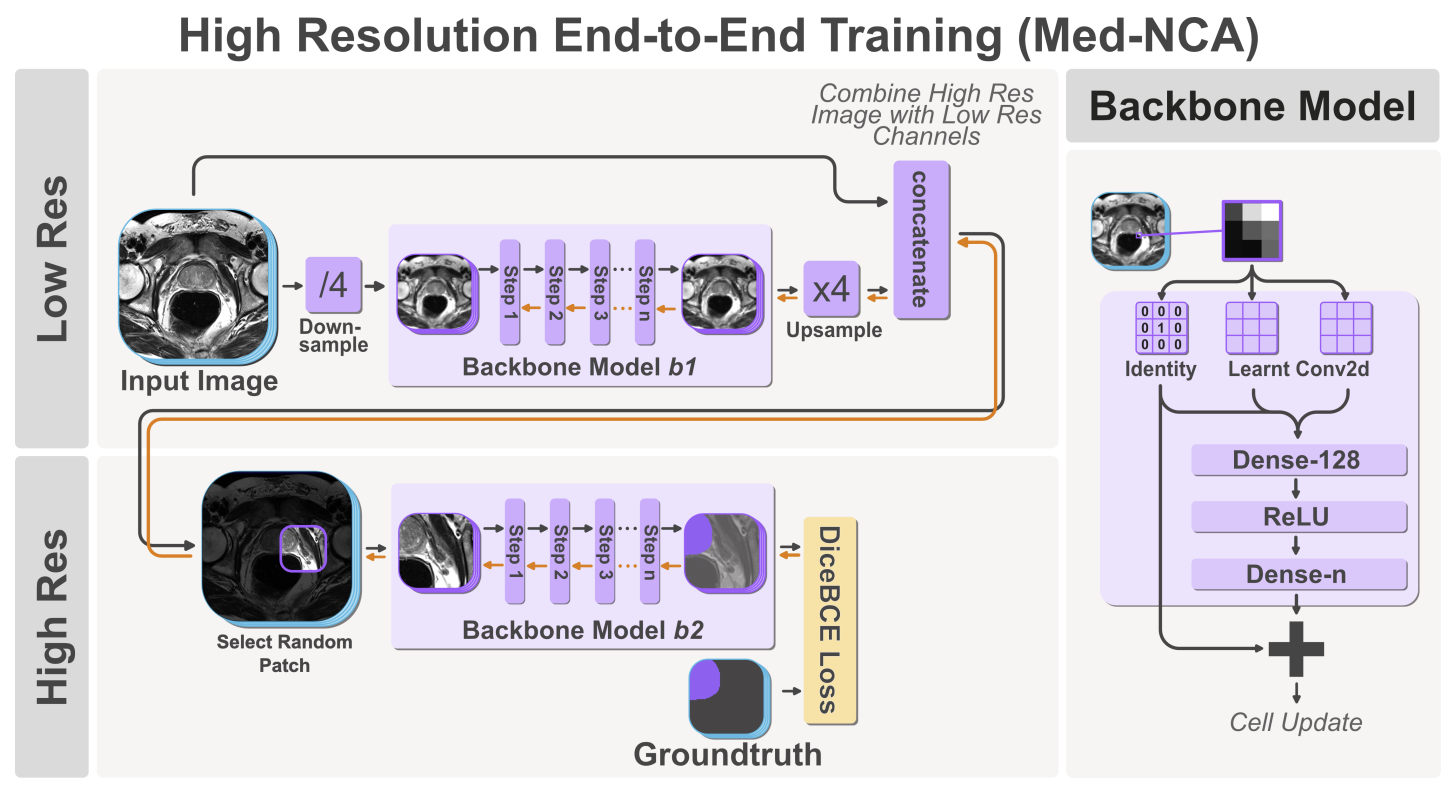

### 2.1 · Training

In [ ]:
seg_nca = L.MedNCA(channels=16, hidden=64, s1=16, s2=16)
seg_unet = L.TinyUNet(base=4)
print(f"Med-NCA: {L.n_params(seg_nca):,} parameters  |  U-Net: {L.n_params(seg_unet):,} parameters")
print("\nMed-NCA")
hs_nca = L.train_model(seg_nca, "seg", hippo, DEVICE, budget_s=LIVE_S, eval_every_s=15, bs=32)
print("\nU-Net")
hs_unet = L.train_model(seg_unet, "seg", hippo, DEVICE, budget_s=LIVE_S, eval_every_s=15, bs=32)

Med-NCA: 10,784 parameters  |  U-Net: 30,645 parameters

Med-NCA
  it    184  ep   1.54  t   15.0s  loss 0.4899  val 0.6605


In [ ]:
ref_med = load_reference("seg_mednca_h64_s16-16")
ref_regen = load_reference("seg_mednca_regen")  # trained with random steps and random cell erasure
ref_unet = load_reference("seg_unet_b4")
ref_unet_big = load_reference("seg_unet_b16")
test_imgs = L.gray_to_tensor(hippo["test_images"], "cpu")
test_masks = torch.as_tensor(hippo["test_masks"]).float()


def dice_of(model, x=test_imgs, m=test_masks, **kw):
    prob, _ = L.predict_seg(model, x, DEVICE, **kw)
    return float(L.dice_score(prob > 0.5, m).mean())


rows = [("Med-NCA (live)", seg_nca), ("U-Net (live)", seg_unet), ("Med-NCA (reference)", ref_med),
        ("U-Net, same size (reference)", ref_unet), ("U-Net, 45x larger (reference)", ref_unet_big)]
if ref_regen is not None:
    rows.append(("Med-NCA, regenerating (reference)", ref_regen))
for name, m in rows:
    if m is not None:
        d = dice_of(m)
        SCORE[f"seg · {name} · Dice"] = d
        print(f"{name:34s} {L.n_params(m):>8,} parameters   test Dice {d:.3f}")

With approximately 11k parameters, Med-NCA matches or exceeds a U-Net with 45 times as many parameters,
consistent with the original publication.

### 2.2 · Evolution of the segmentation over NCA steps

In [ ]:
from matplotlib import animation  # noqa: E402

show = W.pick_slices(hippo["test_images"], hippo["test_masks"], hippo["test_pids"], n=4)
xs = test_imgs[show].to(DEVICE)
frames = []
with torch.no_grad():
    ref_med(xs, hook2=lambda t, x: (frames.append(torch.sigmoid(x[:, 1]).cpu().numpy()), x)[1])
fig, axs = plt.subplots(1, 4, figsize=(7.2, 2.1), dpi=80)
ims = []
for a, k in zip(axs, range(4)):
    a.grid(False); a.imshow(hippo["test_images"][show[k]], cmap="gray"); a.axis("off")
    ims.append(a.imshow(frames[0][k], cmap="magma", alpha=0.55, vmin=0, vmax=1))
    a.contour(hippo["test_masks"][show[k]], levels=[0.5], colors="#5fd4a0", linewidths=1)


def grow(t):
    for k, im in enumerate(ims):
        im.set_data(frames[t][k])
    fig.suptitle(f"fine-stage step {t + 1}/{len(frames)}   ·   green: reference", fontsize=9)
    return ims


anim = animation.FuncAnimation(fig, grow, frames=len(frames), interval=180)
plt.close(fig)
display(show_animation(anim, width=620))

### 2.3 · Change of resolution
As in Section 4.3, the models were trained at 64 px and are evaluated on the same slices upsampled to 96 and
128 px. The U-Net has a fixed receptive field; the NCA operates on a larger grid of cells.

In [ ]:
W.place_your_bets("At 128 px, without retraining, what happens to segmentation accuracy?",
                  ["NCA retains it, U-Net does not", "U-Net retains it, NCA does not", "both retain it", "neither"])

In [ ]:
scales = [0.75, 1.0, 1.5, 2.0]
sub = slice(0, 200)
xs_base, ms_base = test_imgs[sub], test_masks[sub]
fig, ax = plt.subplots(figsize=(5.0, 2.3))
res_tab = {}
for lab, model, kw, c in (("Med-NCA, fixed 16x16 global stage", ref_med, dict(coarse_mode="size"), C_NCA),
                          ("Med-NCA, global stage at 1/4 input (original)", ref_med, dict(coarse_mode="factor"), C_ALT),
                          ("U-Net, same size", ref_unet, {}, C_CNN),
                          ("U-Net, 45x larger", ref_unet_big, {}, C_BIG)):
    ys = []
    for sc in scales:
        x, m = L.rescale(sc)(xs_base), L.rescale_mask(ms_base, sc)
        k = dict(kw)
        if L.is_nca(model):  # a larger image needs proportionally more steps
            k |= dict(s1=round(model.s1 * max(sc, 1)), s2=round(model.s2 * max(sc, 1)))
        ys.append(dice_of(model, x, m, **k))
    ax.plot([s * 64 for s in scales], ys, "o-", color=c, label=lab)
    res_tab[lab] = ys
ax.set(xlabel="test resolution (px); training resolution 64 px", ylabel="Dice", ylim=(0, 1),
       xticks=[s * 64 for s in scales], title="Segmentation at unseen resolutions")
legend_below(fig, ax, ncol=2)
plt.show()
for lab, ys in res_tab.items():
    print(f"{lab:55s} " + "  ".join(f"{int(s * 64)} px: {y:.3f}" for s, y in zip(scales, ys)))
SCORE["seg · 128 px, native · Med-NCA vs U-Net"] = f"{res_tab['Med-NCA, fixed 16x16 global stage'][-1]:.2f} vs {res_tab['U-Net, same size'][-1]:.2f}"

**Result.** At twice the training resolution, Med-NCA retains a Dice of approximately 0.81 (a loss of about 3%,
in line with the original publication), whereas both U-Nets fall to approximately 0.2. This holds only if the
global stage operates on a grid of fixed size; with a fixed downsampling factor the NCA degrades as well,
because the first stage no longer covers the structure within its step budget.

### 2.4 · Translation
The hippocampus appears at varying positions in our slices, so both models learn position-independent
features. Here both models were trained on slices in which the structure is always centred, and evaluated with
the structure shifted.

In [ ]:
W.place_your_bets("After training on centred slices, the structure is shifted by 4 px. Which model is affected?",
                  ["U-Net", "NCA", "neither", "both"])

In [ ]:
c_nca, c_unet = load_reference("seg_centred_mednca"), load_reference("seg_centred_unet_b4")
cen = L.load_hippo(BUNDLE, centred=True)
cx, cm = cen["test_images"][:200], cen["test_masks"][:200]
shifts = [0, 4, 8, 12, 16]
fig, ax = plt.subplots(figsize=(4.6, 2.1))
for lab, m, c in (("Med-NCA", c_nca, C_NCA), ("U-Net, same size", c_unet, C_CNN)):
    ys = []
    for s in shifts:
        x = L.gray_to_tensor(np.stack([L.shift_image(i, s, s) for i in cx]), "cpu")
        mm = torch.as_tensor(np.stack([L.shift_image(k, s, s) for k in cm])).float()
        ys.append(dice_of(m, x, mm))
    ax.plot(shifts, ys, "o-", color=c, label=lab)
    print(f"{lab:18s} " + "  ".join(f"{s} px: {y:.3f}" for s, y in zip(shifts, ys)))
ax.set(xlabel="diagonal shift (px)", ylabel="Dice", ylim=(0, 1), xticks=shifts,
       title="Trained on centred slices, evaluated with shifts")
legend_below(fig, ax, ncol=2)
plt.show()

**Result.** A shift of 4 px reduces the U-Net from 0.86 to 0.67 Dice, while Med-NCA remains at 0.85; the NCA
stays ahead up to 16 px (3 seeds: 0.863 / 0.852 / 0.791 / 0.681 / 0.579 vs 0.861 / 0.670 / 0.732 / 0.545 / 0.536
at 0 / 4 / 8 / 12 / 16 px). The U-Net performs better at 8 px than at 4 px: 8 px corresponds to its total
downsampling factor, so this shift is aligned with its pooling grid.

### 2.5 · Interactive perturbation
Both models run in the browser on the image you draw on. Removing image content and adding noise affect both;
erasing cell states affects only the NCA, since the U-Net keeps no state between forward passes. Suggested
experiments: erase the cells over the centre of the hippocampus and watch the mask grow back; remove half of
the structure from the image and compare how the two models respond.

In [ ]:
surgeon = ref_regen if ref_regen is not None else ref_med
ref_unet = ref_unet.to(DEVICE)
W.cell_surgery(surgeon.cpu(), hippo["test_images"], hippo["test_masks"], hippo["test_pids"],
               unet=ref_unet.cpu(),
               title="Interactive perturbation: Med-NCA and U-Net",
               subtitle=("Regenerating Med-NCA" if ref_regen is not None else "Med-NCA") +
               " and the U-Net of the same size, both running in the browser on the image you draw on.")


### 2.6 · Stability beyond the training horizon
The original Med-NCA was trained with 16 fine-stage steps; each perturbation above adds further steps. The
regenerating variant was trained with 16–64 steps and random erasure of cell states.

In [ ]:
sub = slice(0, 300)
steps_long = [8, 16, 32, 64, 128]
fig, ax = plt.subplots(figsize=(4.6, 2.1))
for m, lab, c in ((ref_med.to(DEVICE), "Med-NCA (16 fine-stage steps)", C_MUTED), (ref_regen, "Med-NCA, regenerating", C_NCA)):
    if m is None:
        continue
    ax.plot(steps_long, [dice_of(m.to(DEVICE), test_imgs[sub], test_masks[sub], s2=s) for s in steps_long], "o-", color=c, label=lab)
ax.set(xscale="log", xticks=steps_long, xticklabels=steps_long, xlabel="fine-stage steps at test time", ylabel="Dice",
       ylim=(0, 1), title="Stability beyond the training horizon")
ax.xaxis.set_minor_formatter(plt.NullFormatter())
legend_below(fig, ax, ncol=2)
plt.show()

## 3 · MRI artifacts and quality control

### 3.1 · Artifact robustness
Select an artifact and its severity; the title reports the mean Dice over 150 test slices for Med-NCA and the
U-Net of the same size. TorchIO's motion artifact is excluded: it displaces the anatomy while the reference
segmentation stays in place, so it measures misalignment rather than robustness.

In [ ]:
import ipywidgets as ipw  # noqa: E402

ARENA = slice(0, 150)
ax_imgs, ax_masks = test_imgs[ARENA], test_masks[ARENA]
ex = [3, 60, 120]
ref_med = ref_med.to(DEVICE)


def arena(artifact="ghosting", severity=1.0):
    tf = None if severity == 0 else L.mri_artifact(artifact, severity, seed=0)
    xs = ax_imgs if tf is None else tf(ax_imgs)
    p_nca, _ = L.predict_seg(ref_med, xs, DEVICE)
    p_unet, _ = L.predict_seg(ref_unet, xs, DEVICE)
    d_nca = float(L.dice_score(p_nca > 0.5, ax_masks).mean())
    d_unet = float(L.dice_score(p_unet > 0.5, ax_masks).mean())
    fig, axs = plt.subplots(3, len(ex), figsize=(5.6, 5.4))
    for j, k in enumerate(ex):
        for i, (img, title) in enumerate(((xs[k, 0], "input"), (p_nca[k], "Med-NCA"), (p_unet[k], "U-Net"))):
            axs[i, j].imshow(img, cmap="gray" if i == 0 else "magma", vmin=0, vmax=1)
            axs[i, j].contour(ax_masks[k], levels=[0.5], colors="#5fd4a0", linewidths=0.8)
            axs[i, j].set_xticks([]); axs[i, j].set_yticks([]); axs[i, j].grid(False)
            if j == 0:
                axs[i, j].set_ylabel(title)
    fig.suptitle(f"{artifact}, severity {severity}:  Med-NCA {d_nca:.3f}  |  U-Net {d_unet:.3f}")
    plt.show()


ipw.interact(arena, artifact=["ghosting", "spike", "noise", "bias"],
             severity=ipw.FloatSlider(value=1.0, min=0, max=3, step=0.25, continuous_update=False))

### 3.2 · Label-free quality control
NCA inference is stochastic: at each step a random subset of cells is updated. Where the model is confident,
repeated runs agree; where it is not, they diverge. The NCA quality metric (NQM) of M3D-NCA quantifies this as
the standard deviation over 10 runs divided by the predicted volume. No reference segmentation is required.

In [ ]:
W.place_your_bets("Can the run-to-run variance of the NCA identify its own failures without labels?",
                  ["yes, reliably", "partially", "no"])

In [ ]:
pids = hippo["test_pids"]
keep = np.isin(pids, np.unique(pids)[:20])  # 20 patients
qx, qm, qp = test_imgs[keep], test_masks[keep], pids[keep]
pts = []
for kind, sev in (("clean", 0), ("noise", 0.2), ("ghosting", 2.5), ("spike", 2.0), ("bias", 1.0)):
    xs = qx if sev == 0 else L.mri_artifact(kind, sev, seed=0)(qx)
    mean, std = L.predict_seg(ref_med, xs, DEVICE, n_runs=10)
    for d, q in zip(L.volume_dice(mean, qm, qp), L.nqm(mean, std, qp)):
        pts.append((kind, d, q))
    if kind == "ghosting":
        demo = (xs, mean, std)

fig = plt.figure(figsize=(8.4, 2.8), constrained_layout=False)
a0 = fig.add_axes([0.07, 0.17, 0.40, 0.70])
for kind, c in zip(("clean", "noise", "ghosting", "spike", "bias"), (C_NCA, C_BIG, C_CNN, C_ALT, C_MUTED)):
    p = [(q, d) for k, d, q in pts if k == kind]
    a0.scatter(*zip(*p), s=22, color=c, label=kind)
d_all, q_all = np.array([p[1] for p in pts]), np.array([p[2] for p in pts])
rho = L.spearman(q_all, d_all)
a0.set(xscale="log", xlabel="NQM (10 runs, no labels)", ylabel="Dice per patient",
       title=f"Spearman ρ = {rho:.2f}, AUROC (Dice < 0.8) = {L.auroc(q_all, d_all < 0.8):.2f}")
a0.legend(ncol=2, loc="lower left")
k = int(np.argmax(demo[2].sum((1, 2))))
for j, (im, title, cmap) in enumerate(((demo[0][k, 0], "input with ghosting", "gray"), (demo[1][k], "mean of 10 runs", "magma"),
                                        (demo[2][k], "standard deviation", "magma"))):
    a = fig.add_axes([0.55 + j * 0.150, 0.17, 0.140, 0.70])
    a.imshow(im, cmap=cmap); a.set_title(title); a.axis("off")
plt.show()
SCORE["QC · Spearman(NQM, Dice)"] = rho

**Result.** Higher variance corresponds closely to lower Dice. The NCA indicates when an input lies outside its
training distribution. The underlying uncertainty estimation is discussed in the talk on interpretability
(11:20).

### 3.3 · Full evaluation (3 seeds, all severities)

| Condition | Med-NCA (11k) | U-Net (31k) | U-Net (483k) |
|---|---|---|---|
| clean | **0.846** | 0.822 | 0.833 |
| 2× resolution, no retraining | **0.812** | 0.212 | 0.159 |
| Gaussian noise, σ = 0.2 | **0.649** | 0.507 | 0.244 |
| ghosting, intensity 2.5 | **0.495** | 0.402 | 0.412 |
| spike, intensity 2.0 | **0.504** | 0.468 | 0.429 |
| bias field, coefficient 0.5 | 0.431 | 0.450 | **0.555** |
| contrast × 0.5 | **0.731** | 0.637 | 0.433 |
| 75% of cells erased | **0.791** | – | – |

Med-NCA is more robust in most conditions at a fraction of the model size. The larger U-Net is clearly better
under bias fields.

## 4 · Classification of blood cells

WBC-NCA places the RGB image in the first three channels of every cell, runs the NCA for a fixed number of
steps, applies a channel-wise maximum over all cells and classifies the resulting vector with a small MLP.
There is no convolutional backbone: features emerge from local cell-to-cell communication.

### 4.1 · Training

In [ ]:
nca_cls = L.NCAClassifier(channels=32, hidden=64, steps=16)
cnn_cls = L.TinyCNN()
print(f"NCA: {L.n_params(nca_cls):,} parameters  |  CNN: {L.n_params(cnn_cls):,} parameters")

print("\nNCA")
h_nca = L.train_model(nca_cls, "cls", blood, DEVICE, budget_s=LIVE_S, eval_every_s=15, bs=32)
print("\nCNN")
h_cnn = L.train_model(cnn_cls, "cls", blood, DEVICE, budget_s=LIVE_S, eval_every_s=15, bs=32)

fig, ax = plt.subplots(figsize=(4.4, 2.1))
for h, lab, c in ((h_nca, "NCA", C_NCA), (h_cnn, "CNN", C_CNN)):
    ax.plot([x["time_s"] for x in h], [x["val"] for x in h], "o-", color=c, label=f"{lab}: {h[-1]['val']:.2f}")
ax.set(xlabel="training time (s)", ylabel="validation accuracy", ylim=(0, 1), title="Training under a fixed time budget")
ax.legend(frameon=False)
plt.show()

The CNN converges considerably faster. NCAs back-propagate through every update step, which makes each
iteration slower and gradients noisier. The remaining experiments therefore use reference models of the same
architectures, trained to convergence.

In [ ]:
ref_nca = load_reference("cls_nca_c32_h64_s24-40")   # trained with a random number of steps (24-40)
ref_nca32 = load_reference("cls_nca_c32_h64_s32")    # trained with exactly 32 steps
ref_cnn = load_reference("cls_cnn_small")
ref_wbc = load_reference("cls_wbcnca_paper")         # configuration of the original paper (128 channels, 64 steps)

TEST_N = 200  # fixed subset; keeps each experiment below ~20 s on a T4
Xt = {r: blood["test_x"][r][:TEST_N] for r in (64, 128, 224)}
Yt = torch.as_tensor(blood["test_y"][:TEST_N])


def acc(model, x, **kw):
    return float((L.predict_cls(model, x, DEVICE, bs=50, **kw) == Yt).float().mean())


models_cls = {"NCA": ref_nca, "CNN": ref_cnn}
if ref_wbc is not None:
    models_cls["WBC-NCA (paper configuration)"] = ref_wbc
for name, m in models_cls.items():
    SCORE[f"cls · {name} · accuracy, 64 px"] = acc(m, Xt[64])
    print(f"{name:30s} {L.n_params(m):>7,} parameters   test accuracy {SCORE[f'cls · {name} · accuracy, 64 px']:.3f}")

### 4.2 · Evolution of the prediction over NCA steps
Each frame is one update step; the bars show the class probabilities obtained if inference stopped at that step.

In [ ]:
i_demo = int(np.flatnonzero(Yt.numpy() == 1)[0])  # an eosinophil
x_demo = L.rgb_to_tensor(Xt[64][i_demo:i_demo + 1], DEVICE)
beliefs, states = [], []


def record(t, x):
    with torch.no_grad():
        beliefs.append(torch.softmax(ref_nca.head(x[:, 3:].amax((2, 3))), 1)[0].cpu().numpy())
        states.append(x[0, 3:6].cpu().numpy())
    return x


with torch.no_grad():
    ref_nca(x_demo, steps=40, hook=record)

SHORT = [c.replace("immature granulocyte", "imm. granulocyte") for c in L.BLOOD_CLASSES]
fig, (a0, a1, a2) = plt.subplots(1, 3, figsize=(6.4, 2.0), dpi=80, gridspec_kw={"width_ratios": [1, 1, 1.6]})
a0.grid(False); a0.imshow(Xt[64][i_demo]); a0.set_title(f"input: {L.BLOOD_CLASSES[Yt[i_demo]]}"); a0.axis("off")
a1.grid(False); im1 = a1.imshow(np.zeros((64, 64, 3))); a1.set_title("hidden channels 4-6"); a1.axis("off")
bars = a2.barh(SHORT, beliefs[0], color=C_NCA)
a2.set_xlim(0, 1); a2.invert_yaxis(); a2.grid(False); a2.set_xlabel("probability")


def frame(k):
    im1.set_data(np.clip(0.5 + 0.25 * np.transpose(states[k], (1, 2, 0)), 0, 1))
    for b, v in zip(bars, beliefs[k]):
        b.set_width(v)
    a2.set_title(f"class probabilities, step {k + 1}")
    return [im1, *bars]


anim = animation.FuncAnimation(fig, frame, frames=len(beliefs), interval=150)
plt.close(fig)
display(show_animation(anim, width=700))

### 4.3 · Change of resolution
Both models were trained at 64 px. We evaluate them on the same cells acquired at 128 and 224 px, without
retraining. The NCA has no fixed input size; a larger image simply contains more cells.

In [ ]:
W.place_your_bets("At 224 px, without retraining, which model retains more of its accuracy?",
                  ["NCA", "CNN", "both retain it", "neither"])

In [ ]:
steps_grid = {64: [16, 32, 48], 128: [32, 48, 64], 224: [32, 64, 112]}
res_rows = []
fig, axs = plt.subplots(1, 3, figsize=(6.9, 2.2), sharey=True)
for ax, r in zip(axs, (64, 128, 224)):
    nca_curve = [acc(ref_nca, Xt[r], steps=s) for s in steps_grid[r]]
    cnn_direct = acc(ref_cnn, Xt[r])
    nca_resized = acc(ref_nca, Xt[r], transform=L.rescale(64 / r))
    cnn_resized = acc(ref_cnn, Xt[r], transform=L.rescale(64 / r))
    ax.plot(steps_grid[r], nca_curve, "o-", color=C_NCA, label="NCA, native resolution")
    ax.axhline(cnn_direct, color=C_CNN, label="CNN, native resolution")
    ax.axhline(nca_resized, color=C_NCA, ls=":", label="NCA, resized to 64 px")
    ax.axhline(cnn_resized, color=C_CNN, ls=":", label="CNN, resized to 64 px")
    ax.set(title=f"{r} px", xlabel="NCA steps", ylim=(0, 1))
    res_rows.append((r, max(nca_curve), cnn_direct, nca_resized, cnn_resized))
axs[0].set_ylabel("test accuracy")
legend_below(fig, axs[0], ncol=4)
plt.show()
for r, n, c, nr, cr in res_rows:
    print(f"{r:>3} px   NCA {n:.2f}   CNN {c:.2f}")  # dotted lines in the figure: input resized to 64 px
SCORE["cls · 224 px, native · NCA vs CNN"] = f"{res_rows[-1][1]:.2f} vs {res_rows[-1][2]:.2f}"

**Result.** The NCA degrades less than the CNN (at 224 px roughly 0.5 vs 0.2–0.3), but both lose most of their
accuracy, and resizing the input to the training resolution outperforms both. The NCA has learned features at a
fixed pixel scale: an architecture without a fixed input size is not automatically scale-invariant.

### 4.4 · Number of steps and cell damage
Inference is an iterated map. We vary the number of steps at test time and, separately, erase the hidden state
of a fraction of the cells halfway through inference.

In [ ]:
fig, (a0, a1) = plt.subplots(1, 2, figsize=(6.2, 2.2))
long_steps = [16, 32, 64, 128]
for m, lab, c in ((ref_nca32, "trained with 32 steps", C_MUTED), (ref_nca, "trained with 24–40 steps (random)", C_NCA)):
    if m is None:
        continue
    a0.plot(long_steps, [acc(m, Xt[64], steps=s) for s in long_steps], "o-", color=c, label=lab)
    fr = [0, 0.25, 0.5, 0.75]
    a1.plot([f * 100 for f in fr], [acc(m, Xt[64], hook=L.random_cell_damage(f, 16, 3)) for f in fr], "o-", color=c, label=lab)
a0.set(xscale="log", xticks=long_steps, xticklabels=long_steps, xlabel="steps at test time", ylabel="accuracy", ylim=(0, 1),
       title="Number of steps at test time")
a0.xaxis.set_minor_formatter(plt.NullFormatter())
a1.set(xlabel="% of cells erased at step 16", ylim=(0, 1), title="Cell damage during inference")
legend_below(fig, a0, ncol=2)
plt.show()

**Result.** Training with a random number of steps yields a stable dynamical system; the model trained with a
fixed 32 steps collapses at 64. Both models tolerate the loss of half of their cells.

## 5 · Summary

In [ ]:
for k, v in SCORE.items():
    print(f"{k:55s} {v:.3f}" if isinstance(v, float) else f"{k:55s} {v}")

1. **Efficiency.** A Med-NCA with about 11k parameters outperforms a U-Net with 483k parameters on hippocampus
   segmentation (Dice 0.846 vs 0.833) and remains more accurate under noise, ghosting, spikes and reduced contrast.
2. **Resolution.** At twice the training resolution, Med-NCA retains a Dice of 0.81 while both U-Nets fall below
   0.22, provided the global stage covers the entire image.
3. **Limitations.** For blood-cell classification the CNN of similar size is more accurate and converges faster,
   and resizing to the training resolution outperforms resolution transfer for both models.
4. **Dynamics.** Training with a variable number of steps and with cell damage yields models that are stable over
   long rollouts and recover from damage; a fixed number of steps does not.
5. **Quality control.** The variance across stochastic runs predicts segmentation failure without labels.

Hands-on Session 3 extends NCAs to detection and simulation.

**Further material.** Label-free adaptation to a new scanner by minimising this variance (Kalkhof et al.,
MICCAI 2024) improves Dice under noise (0.61 → 0.77) but degrades it under ghosting, where the model is
consistently wrong.

**References.** Mordvintsev et al., Growing Neural Cellular Automata, Distill 2020 · Randazzo et al.,
Self-classifying MNIST Digits, Distill 2020 · Kalkhof et al., Med-NCA, IPMI 2023 · Kalkhof & Mukhopadhyay,
M3D-NCA, MICCAI 2023 · Deutges et al., WBC-NCA, MICCAI 2024 · Kalkhof et al., Unsupervised Training of NCAs on
Edge Devices, MICCAI 2024 · Yang et al., Hierarchical NCA, IPMI 2025.